# 31 — Assembly101 Qwen catalog-conditioned direct top-1 alignment

This notebook implements Federico's closed-set follow-up on the **validation split only**.

Important distinction from Notebook 24:

- Notebook 24 already included the complete 202-class catalog, but asked Qwen for a caption and one hard class per step.
- Notebook 31 removes free-caption generation, presents the same full catalog explicitly, processes four 4-frame temporal blocks, and asks for one exact class ID with confidence per step.
- The predeclared primary representation is the CLIP prototype of that directly selected class.
- Fixed temporal smoothing and shuffled predictions are diagnostics; they are not searched or selected after evaluation.

The notebook never loads validation labels during Qwen generation. Labels are loaded only after all pseudo-text artifacts have been frozen.


## Experimental contract

**Primary metric:** validation F1@50.

**Primary candidate:** teacher + Qwen direct closed-set top-1 embedding.

**Promotion gate (fixed before results):**

1. full-validation F1@50 gain over the visual-only MS-TCN is at least +0.30;
2. calibration F1@50 delta is non-negative;
3. untouched holdout F1@50 delta is non-negative;
4. the primary candidate beats the previous Notebook-24 hard top-1 pseudo-text.

Failure of the gate means that Qwen pseudo-text is reported as a negative follow-up and is not evaluated on the test set.


## 1. Mount Google Drive


In [46]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


## 2. Install dependencies


In [47]:
# %pip install -U \
#   "transformers>=5.14.0,<6" \
#   accelerate safetensors \
#   "huggingface_hub[hf_xet]" \
#   decord rapidfuzz pillow pandas tqdm matplotlib

## 3. Imports, deterministic settings, and GPU audit


In [48]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import subprocess
import time
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
from decord import VideoReader, cpu
from huggingface_hub import get_token, hf_hub_download, login, notebook_login
from tqdm.auto import tqdm
from transformers import AutoModelForMultimodalLM, AutoProcessor

os.environ["TOKENIZERS_PARALLELISM"] = "false"
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 260)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError(
        "Notebook 31 requires a CUDA GPU for Qwen extraction. "
        "In Colab select Runtime -> Change runtime type -> GPU."
    )

GPU_NAME = torch.cuda.get_device_name(0)
GPU_TOTAL_GIB = torch.cuda.get_device_properties(0).total_memory / 1024**3
MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("GPU:", GPU_NAME)
print("GPU memory:", f"{GPU_TOTAL_GIB:.2f} GiB")
print("Qwen dtype:", MODEL_DTYPE)
subprocess.run(["nvidia-smi"], check=False)

if GPU_TOTAL_GIB < 10:
    raise RuntimeError("The frozen Qwen3.5-2B protocol expects at least 10 GiB GPU memory.")


Python: 3.13.15
PyTorch: 2.11.0+cu128
GPU: Tesla T4
GPU memory: 14.56 GiB
Qwen dtype: torch.bfloat16


## 4. Locked configuration and paths


In [49]:
# Generation is validation-only. Test access stays locked.
RUN_MODE = "validation"
TARGET_SPLIT = "validation"
ALLOW_TEST_GENERATION = False

RUN_CONFIGS = {
    "smoke": {"cohort_size": 2, "max_recordings_per_session": 2},
    "validation": {"cohort_size": None, "max_recordings_per_session": 8},
}
if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")
CFG = RUN_CONFIGS[RUN_MODE]

QWEN_MODEL_ID = "Qwen/Qwen3.5-2B"
EXPERIMENT_ID = "qwen35_2b_catalog_top1_lines4_v3"
PROMPT_VERSION = "catalog_top1_id_score_lines4_v3"

EXPECTED_NUM_CLASSES = 202
EXPECTED_TEXT_DIM = 512
EXPECTED_VIDEO_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
NUM_TEMPORAL_STEPS = 16
FRAMES_PER_PROMPT = 4
TOP_K = 1
FRAME_SIDE = 224
PROCESSOR_MAX_IMAGE_PIXELS = FRAME_SIDE * FRAME_SIDE
JPEG_QUALITY = 92
MAX_NEW_TOKENS = 512
MAX_GENERATION_ATTEMPTS = 2
TEMPORAL_SELF_WEIGHT = 0.80
TEMPORAL_NEIGHBOR_WEIGHT = 0.10

FORCE_REGENERATE = False
DELETE_TEMP_FRAMES = True
MAX_SESSION_HOURS = 7.0
STOP_BUFFER_MINUTES = 35
MAX_DOWNLOAD_ATTEMPTS = 3
RETRY_SLEEP_SECONDS = 10

PRIMARY_VARIANT = "n31_top1"
MIN_REQUIRED_FULL_F1_50_GAIN = 0.30

REPO_ID = "cvml-nus/assembly101"
REPO_TYPE = "dataset"

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
ASSEMBLY_ROOT = DRIVE_ROOT / "assembly101"
MSTCN_ROOT = (
    DRIVE_ROOT / "text_assisted_tas" / "assembly101"
    / "coarse_mstcn_format"
)
FEATURE_ROOT = MSTCN_ROOT / "streaming_visual_features_v1"
CLIP_ROOT = FEATURE_ROOT / "clip_vitb16"

SEQUENCE_MANIFEST_DRIVE = MSTCN_ROOT / "procedurevrl_extraction_manifest_v1.csv"
RECORDING_MANIFEST_DRIVE = MSTCN_ROOT / "recording_download_manifest_v1.csv"
REMOTE_SIZE_INVENTORY_DRIVE = MSTCN_ROOT / "v1_download" / "remote_size_inventory_v1.csv"
NOTEBOOK14_SUMMARY_DRIVE = MSTCN_ROOT / "v1_download" / "assembly101_v1_download_summary.json"
TEXT_EMBEDDING_DRIVE = CLIP_ROOT / "text_embeddings" / "assembly101_coarse_clip_vitb16_text_embeddings.npy"
TEXT_METADATA_DRIVE = CLIP_ROOT / "text_embeddings" / "assembly101_coarse_clip_vitb16_text_metadata.csv"

NOTEBOOK24_ROOT_DRIVE = (
    FEATURE_ROOT / "runs" / "24_qwen35_pseudotext"
    / "qwen35_2b_closedset_temporal_v1"
)
NOTEBOOK25_SUMMARY_DRIVE = (
    FEATURE_ROOT / "runs" / "25_qwen_pseudotext_teacher_validation"
    / "final_summary.json"
)
NOTEBOOK18_ROOT_DRIVE = FEATURE_ROOT / "runs" / "18_text_assisted_concat_teachers"
NOTEBOOK18_SUMMARY_DRIVE = NOTEBOOK18_ROOT_DRIVE / "final_summary_full.json"
TEACHER_ROOT_DRIVE = NOTEBOOK18_ROOT_DRIVE / "mstcn" / "clip_vitb16" / "full"
TEACHER_CHECKPOINT_DRIVE = TEACHER_ROOT_DRIVE / "models" / "best_teacher.pt"
TRAIN_VIDEO_MEAN_DRIVE = TEACHER_ROOT_DRIVE / "results" / "train_video_mean.npy"
TRAIN_VIDEO_STD_DRIVE = TEACHER_ROOT_DRIVE / "results" / "train_video_std.npy"
NOTEBOOK28_CACHE_DRIVE = (
    FEATURE_ROOT / "runs" / "28_residual_pseudotext_logit_fusion"
    / "validation_logits_cache.npz"
)

DRIVE_OUT_ROOT = FEATURE_ROOT / "runs" / "31_qwen_catalog_top1_alignment" / EXPERIMENT_ID
DRIVE_PARSED_DIR = DRIVE_OUT_ROOT / "parsed_predictions"
DRIVE_PROBABILITY_DIR = DRIVE_OUT_ROOT / "class_probabilities"
DRIVE_TOP1_DIR = DRIVE_OUT_ROOT / "top1_embeddings"
DRIVE_SOFT_DIR = DRIVE_OUT_ROOT / "score_weighted_embeddings"
DRIVE_TEMPORAL_DIR = DRIVE_OUT_ROOT / "top1_temporal_embeddings"
DRIVE_RAW_DIR = DRIVE_OUT_ROOT / "raw_responses"
DRIVE_ARTIFACT_DIR = DRIVE_OUT_ROOT / "presentation_artifacts"

LOCAL_RUNTIME_ROOT = Path("/content/nb31_runtime")
LOCAL_INPUT_ROOT = LOCAL_RUNTIME_ROOT / "inputs"
LOCAL_VIDEO_ROOT = LOCAL_RUNTIME_ROOT / "videos"
LOCAL_FRAME_ROOT = LOCAL_RUNTIME_ROOT / "frames"
# The reused deterministic sampling helper from notebook 24 expects this name.
TEMP_FRAME_ROOT = LOCAL_FRAME_ROOT
LOCAL_OUT_ROOT = LOCAL_RUNTIME_ROOT / "outputs"
LOCAL_PARSED_DIR = LOCAL_OUT_ROOT / "parsed_predictions"
LOCAL_PROBABILITY_DIR = LOCAL_OUT_ROOT / "class_probabilities"
LOCAL_TOP1_DIR = LOCAL_OUT_ROOT / "top1_embeddings"
LOCAL_SOFT_DIR = LOCAL_OUT_ROOT / "score_weighted_embeddings"
LOCAL_TEMPORAL_DIR = LOCAL_OUT_ROOT / "top1_temporal_embeddings"
LOCAL_RAW_DIR = LOCAL_OUT_ROOT / "raw_responses"
LOCAL_ARTIFACT_DIR = LOCAL_OUT_ROOT / "presentation_artifacts"

for path in [
    DRIVE_OUT_ROOT, DRIVE_PARSED_DIR, DRIVE_PROBABILITY_DIR,
    DRIVE_TOP1_DIR, DRIVE_SOFT_DIR, DRIVE_TEMPORAL_DIR,
    DRIVE_RAW_DIR, DRIVE_ARTIFACT_DIR,
    LOCAL_INPUT_ROOT, LOCAL_VIDEO_ROOT, LOCAL_FRAME_ROOT,
    LOCAL_OUT_ROOT, LOCAL_PARSED_DIR, LOCAL_PROBABILITY_DIR,
    LOCAL_TOP1_DIR, LOCAL_SOFT_DIR, LOCAL_TEMPORAL_DIR,
    LOCAL_RAW_DIR, LOCAL_ARTIFACT_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

if TARGET_SPLIT.lower() == "test" and not ALLOW_TEST_GENERATION:
    raise RuntimeError("Test generation is locked by the experimental contract.")

print("RUN_MODE:", RUN_MODE)
print("Experiment:", EXPERIMENT_ID)
print("Persistent output:", DRIVE_OUT_ROOT)


RUN_MODE: validation
Experiment: qwen35_2b_catalog_top1_lines4_v3
Persistent output: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/31_qwen_catalog_top1_alignment/qwen35_2b_catalog_top1_lines4_v3


## 5. Robust Google Drive I/O


In [50]:
def remount_google_drive():
    print("Google Drive connection was lost. Remounting...")
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    time.sleep(2)
    drive.mount("/content/drive", force_remount=True)


def copy_with_retry(source, destination, max_attempts=5, overwrite=True):
    source = Path(source)
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".part")

    for attempt in range(1, max_attempts + 1):
        try:
            destination.parent.mkdir(parents=True, exist_ok=True)
            if not overwrite and destination.exists() and destination.stat().st_size > 0:
                return destination
            if temporary.exists():
                temporary.unlink()
            expected_size = source.stat().st_size
            shutil.copyfile(source, temporary)
            if temporary.stat().st_size != expected_size:
                raise OSError(f"Incomplete copy: {source}")
            temporary.replace(destination)
            return destination
        except OSError as error:
            try:
                if temporary.exists():
                    temporary.unlink()
            except OSError:
                pass
            if attempt == max_attempts:
                raise
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)


def drive_file_available(path, max_attempts=4):
    path = Path(path)
    for attempt in range(1, max_attempts + 1):
        try:
            return path.exists() and path.stat().st_size > 0
        except OSError as error:
            if attempt == max_attempts:
                return False
            if error.errno == 107:
                remount_google_drive()
            else:
                time.sleep(2 * attempt)
    return False


def save_json_local(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, ensure_ascii=False), encoding="utf-8")
    temporary.replace(path)


def save_npy_local(path, value):
    path = Path(path)
    temporary = path.with_name(path.stem + ".tmp.npy")
    np.save(temporary, value)
    temporary.replace(path)


print("Robust I/O helpers ready.")


Robust I/O helpers ready.


## 6. Authenticate with Hugging Face


In [51]:
def authenticate_huggingface():
    token = None

    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")
    except Exception:
        token = None

    if token:
        login(token=token, add_to_git_credential=False)
        print("Authenticated using the Colab secret HF_TOKEN.")
        return

    if get_token() is not None:
        print("A Hugging Face token is already available.")
        return

    notebook_login(skip_if_logged_in=True)


authenticate_huggingface()

if get_token() is None:
    raise RuntimeError("Hugging Face authentication did not complete.")


Authenticated using the Colab secret HF_TOKEN.


## 7. Stage and validate generation inputs


In [52]:
generation_inputs = {
    "sequence_manifest.csv": SEQUENCE_MANIFEST_DRIVE,
    "recording_manifest.csv": RECORDING_MANIFEST_DRIVE,
    "remote_size_inventory.csv": REMOTE_SIZE_INVENTORY_DRIVE,
    "notebook14_summary.json": NOTEBOOK14_SUMMARY_DRIVE,
    "text_embeddings.npy": TEXT_EMBEDDING_DRIVE,
    "text_metadata.csv": TEXT_METADATA_DRIVE,
}

local_generation_paths = {}
for local_name, drive_path in tqdm(generation_inputs.items(), desc="Stage generation inputs"):
    if not drive_file_available(drive_path):
        raise FileNotFoundError(f"Missing prerequisite: {drive_path}")
    local_path = LOCAL_INPUT_ROOT / local_name
    copy_with_retry(drive_path, local_path)
    local_generation_paths[local_name] = local_path

sequences = pd.read_csv(local_generation_paths["sequence_manifest.csv"])
recordings = pd.read_csv(local_generation_paths["recording_manifest.csv"])
remote_sizes = pd.read_csv(local_generation_paths["remote_size_inventory.csv"])
notebook14_summary = json.loads(
    local_generation_paths["notebook14_summary.json"].read_text(encoding="utf-8")
)

required_sequence_columns = {
    "sequence_id", "split", "recording_name", "video_remote_path",
    "clip_start_seconds", "clip_end_seconds",
}
required_recording_columns = {"recording_name", "video_remote_path"}
if required_sequence_columns - set(sequences.columns):
    raise KeyError(f"Missing sequence columns: {sorted(required_sequence_columns - set(sequences.columns))}")
if required_recording_columns - set(recordings.columns):
    raise KeyError(f"Missing recording columns: {sorted(required_recording_columns - set(recordings.columns))}")

size_key = "recording_name" if "recording_name" in remote_sizes.columns else "video_remote_path"
recordings = recordings.drop(
    columns=["remote_size_bytes", "remote_size_gib"], errors="ignore"
).merge(
    remote_sizes[[size_key, "remote_size_bytes"]].drop_duplicates(size_key),
    on=size_key,
    how="left",
    validate="one_to_one",
)
if recordings["remote_size_bytes"].isna().any():
    raise RuntimeError("Some recordings have no remote size.")
recordings["remote_size_bytes"] = recordings["remote_size_bytes"].astype("int64")
recordings["remote_size_gib"] = recordings["remote_size_bytes"] / 1024**3

def canonical_split(value):
    value = str(value).strip().lower()
    if value in {"val", "valid", "validation"}:
        return "validation"
    if value in {"train", "training"}:
        return "train"
    if value in {"test", "testing"}:
        return "test"
    return value

sequences["canonical_split"] = sequences["split"].map(canonical_split)
TARGET_SPLIT_CANONICAL = canonical_split(TARGET_SPLIT)
PINNED_REVISION = str(notebook14_summary["pinned_revision"])

text_embeddings = np.load(local_generation_paths["text_embeddings.npy"]).astype(np.float32)
text_metadata = pd.read_csv(local_generation_paths["text_metadata.csv"]).sort_values(
    "model_class_id"
).reset_index(drop=True)

if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text embedding shape: {text_embeddings.shape}")
if not np.array_equal(text_metadata["model_class_id"].to_numpy(), np.arange(EXPECTED_NUM_CLASSES)):
    raise ValueError("Text metadata must cover class IDs 0..201 in order.")

text_embeddings /= np.maximum(np.linalg.norm(text_embeddings, axis=1, keepdims=True), 1e-12)
text_embeddings = text_embeddings.astype(np.float32)
ACTION_LABELS = text_metadata["action_cls"].astype(str).tolist()
ID_TO_LABEL = dict(enumerate(ACTION_LABELS))

target_sequences = sequences[
    sequences["canonical_split"] == TARGET_SPLIT_CANONICAL
].copy().merge(
    recordings[["recording_name", "video_remote_path", "remote_size_bytes", "remote_size_gib"]],
    on="recording_name",
    how="left",
    suffixes=("", "_recording"),
    validate="many_to_one",
).sort_values(["remote_size_bytes", "recording_name", "clip_start_seconds", "sequence_id"]).reset_index(drop=True)

if len(target_sequences) != 120:
    raise RuntimeError(f"Expected 120 validation sequences, got {len(target_sequences)}")

print("Pinned revision:", PINNED_REVISION)
print("Catalog classes:", len(ACTION_LABELS))
print("Validation sequences:", len(target_sequences))
display(text_metadata.head(20))


Stage generation inputs:   0%|          | 0/6 [00:00<?, ?it/s]

Pinned revision: bfc15ea5e3f0bc8f8c232af6c1b45aa137a9d967
Catalog classes: 202
Validation sequences: 120


,model_class_id,official_action_id,action_cls,verb_cls,noun_cls,prompt,clip_model
0,0,0,inspect toy,inspect,toy,a video of a person performing the action: inspect toy,ViT-B/16
1,1,1,attach cabin,attach,cabin,a video of a person performing the action: attach cabin,ViT-B/16
2,2,2,detach cabin,detach,cabin,a video of a person performing the action: detach cabin,ViT-B/16
3,3,3,detach wheel,detach,wheel,a video of a person performing the action: detach wheel,ViT-B/16
4,4,4,attach wheel,attach,wheel,a video of a person performing the action: attach wheel,ViT-B/16
5,5,5,screw chassis,screw,chassis,a video of a person performing the action: screw chassis,ViT-B/16
6,6,6,demonstrate functionality,demonstrate,functionality,a video of a person performing the action: demonstrate functionality,ViT-B/16
7,7,7,unscrew chassis,unscrew,chassis,a video of a person performing the action: unscrew chassis,ViT-B/16
8,8,8,attach interior,attach,interior,a video of a person performing the action: attach interior,ViT-B/16
9,9,9,detach roof,detach,roof,a video of a person performing the action: detach roof,ViT-B/16


## 8. Freeze the full-catalog compact top-1 prompt


In [53]:
LABEL_CATALOG_TEXT = "\n".join(
    f"{class_id}: {label}" for class_id, label in ID_TO_LABEL.items()
)

PROMPT_PREFIX = (
    "You are performing closed-set temporal action recognition for Assembly101.\n"
    "Inspect the ordered egocentric frames and select actions only from the complete "
    "catalog below. First reason internally about the manipulated object and hand motion, "
    "but output only the requested compact lines. Do not produce captions, explanations, "
    "Markdown, or JSON.\n\n"
)

def build_catalog_prompt(step_indices):
    step_indices = [int(index) for index in step_indices]
    output_slots = ",".join(["<label_id>:<score>"] * TOP_K)
    return (
        PROMPT_PREFIX
        + f"The {len(step_indices)} frames correspond in order to global temporal steps "
        + f"{step_indices}. Return exactly one line for every listed step.\n"
        + f"For each step return exactly {TOP_K} different label_id values from 0 to "
        + f"{EXPECTED_NUM_CLASSES - 1}, ordered from most to least likely. "
        + "Scores must be non-negative and should sum to 1 for each step.\n"
        + "Use this literal line format, replacing the placeholders with numbers:\n"
        + f"STEP <global_step> | {output_slots}\n"
        + "Do not copy placeholder text. Do not invent IDs outside the catalog.\n"
        + "Base every line on its corresponding image; do not reuse a demonstration answer.\n"
        + "\n\nRules:\n"
        + "- Use only IDs from the catalog.\n"
        + "- Never repeat an ID within one step.\n"
        + "- Return only the requested lines, without a code fence.\n"
        + "- Do not use knowledge of the ground-truth sequence.\n\n"
        + "Complete allowed action catalog:\n"
        + LABEL_CATALOG_TEXT
    )

PROMPT_CONTRACT = (
    PROMPT_PREFIX + LABEL_CATALOG_TEXT
    + f"|top_k={TOP_K}|frames_per_prompt={FRAMES_PER_PROMPT}|version={PROMPT_VERSION}"
)
PROMPT_HASH = hashlib.sha256(PROMPT_CONTRACT.encode("utf-8")).hexdigest()

frozen_config = {
    "experiment_id": EXPERIMENT_ID,
    "model_id": QWEN_MODEL_ID,
    "prompt_version": PROMPT_VERSION,
    "prompt_sha256": PROMPT_HASH,
    "catalog_size": EXPECTED_NUM_CLASSES,
    "top_k": TOP_K,
    "frames_per_prompt": FRAMES_PER_PROMPT,
    "num_temporal_steps": NUM_TEMPORAL_STEPS,
    "generation": {"do_sample": False, "max_new_tokens": MAX_NEW_TOKENS},
    "primary_variant": PRIMARY_VARIANT,
    "test_accessed": False,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
save_json_local(LOCAL_OUT_ROOT / "frozen_config.json", frozen_config)
copy_with_retry(LOCAL_OUT_ROOT / "frozen_config.json", DRIVE_OUT_ROOT / "frozen_config.json")

print("Prompt SHA256:", PROMPT_HASH)
print("Catalog size:", EXPECTED_NUM_CLASSES)
print("Example prompt characters:", len(build_catalog_prompt(range(FRAMES_PER_PROMPT))))


Prompt SHA256: 761b9ec4275358e9c3389029d26565daa220e49b29257c89abd613028b501056
Catalog size: 202
Example prompt characters: 5601


## 9. Resumable cohort selection


In [54]:
def sequence_output_paths(root, sequence_id):
    root = Path(root)
    return {
        "metadata": root / "parsed_predictions" / f"{sequence_id}.json",
        "probabilities": root / "class_probabilities" / f"{sequence_id}.npy",
        "top1": root / "top1_embeddings" / f"{sequence_id}.npy",
        "soft": root / "score_weighted_embeddings" / f"{sequence_id}.npy",
        "temporal": root / "top1_temporal_embeddings" / f"{sequence_id}.npy",
    }


def saved_output_is_valid(sequence_id, refresh_local=False):
    drive_paths = sequence_output_paths(DRIVE_OUT_ROOT, sequence_id)
    local_paths = sequence_output_paths(LOCAL_OUT_ROOT, sequence_id)

    if not all(drive_file_available(path) for path in drive_paths.values()):
        return False

    try:
        for key in drive_paths:
            if refresh_local or not local_paths[key].exists():
                copy_with_retry(drive_paths[key], local_paths[key])

        metadata = json.loads(local_paths["metadata"].read_text(encoding="utf-8"))
        probabilities = np.load(local_paths["probabilities"])
        top1 = np.load(local_paths["top1"])
        soft = np.load(local_paths["soft"])
        temporal = np.load(local_paths["temporal"])

        return bool(
            metadata.get("prompt_sha256") == PROMPT_HASH
            and metadata.get("model_id") == QWEN_MODEL_ID
            and metadata.get("ground_truth_used") is False
            and probabilities.shape == (NUM_TEMPORAL_STEPS, EXPECTED_NUM_CLASSES)
            and top1.shape == (EXPECTED_TEXT_DIM, NUM_TEMPORAL_STEPS)
            and soft.shape == (EXPECTED_TEXT_DIM, NUM_TEMPORAL_STEPS)
            and temporal.shape == (EXPECTED_TEXT_DIM, NUM_TEMPORAL_STEPS)
            and np.isfinite(probabilities).all()
            and np.isfinite(top1).all()
            and np.isfinite(soft).all()
            and np.isfinite(temporal).all()
            and np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5)
        )
    except Exception:
        return False


cohort = (
    target_sequences.head(CFG["cohort_size"]).copy()
    if CFG["cohort_size"] is not None
    else target_sequences.copy()
)
cohort["complete_before_run"] = cohort["sequence_id"].astype(str).map(saved_output_is_valid)

selected_sequences = (
    cohort.copy()
    if FORCE_REGENERATE
    else cohort[~cohort["complete_before_run"]].copy()
)

recording_queue = (
    selected_sequences.groupby("recording_name", as_index=False)
    .agg(
        pending_sequences=("sequence_id", "size"),
        remote_size_bytes=("remote_size_bytes", "first"),
        remote_size_gib=("remote_size_gib", "first"),
    )
    .sort_values(["remote_size_bytes", "recording_name"])
    .head(CFG["max_recordings_per_session"])
    .reset_index(drop=True)
)

print("Fixed cohort:", len(cohort))
print("Already complete:", int(cohort["complete_before_run"].sum()))
print("Pending:", len(selected_sequences))
print("Recordings scheduled this session:", len(recording_queue))
display(recording_queue)


Fixed cohort: 120
Already complete: 120
Pending: 0
Recordings scheduled this session: 0


,recording_name,pending_sequences,remote_size_bytes,remote_size_gib


## 10. Load Qwen3.5-2B only when work remains


In [55]:
torch.cuda.empty_cache()
gc.collect()

if recording_queue.empty:
    processor = None
    model = None
    MODEL_DEVICE = torch.device("cuda")
    print("No pending sequences: Qwen loading skipped.")
else:
    processor = AutoProcessor.from_pretrained(
        QWEN_MODEL_ID,
        max_image_size={"longest_edge": PROCESSOR_MAX_IMAGE_PIXELS},
    )
    processor.tokenizer.padding_side = "left"
    model = AutoModelForMultimodalLM.from_pretrained(
        QWEN_MODEL_ID,
        dtype=MODEL_DTYPE,
        device_map="auto",
        low_cpu_mem_usage=True,
        attn_implementation="sdpa",
    )
    model.eval()
    MODEL_DEVICE = next(model.parameters()).device
    print("Model device:", MODEL_DEVICE)
    print("Parameters:", f"{sum(p.numel() for p in model.parameters()) / 1e9:.3f} B")


No pending sequences: Qwen loading skipped.


## 11. Deterministic frame sampling


In [56]:
CENTER_POSITIONS = (
    np.arange(NUM_TEMPORAL_STEPS, dtype=np.float64) + 0.5
) / NUM_TEMPORAL_STEPS

def letterbox_frame(frame, side=FRAME_SIDE):
    image = Image.fromarray(frame).convert("RGB")
    image = ImageOps.contain(image, (side, side), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (side, side), color=(0, 0, 0))
    offset = ((side - image.width) // 2, (side - image.height) // 2)
    canvas.paste(image, offset)
    return canvas


def sample_sequence_frames(
    video_path,
    clip_start_seconds,
    clip_end_seconds,
):
    video_reader = VideoReader(str(video_path), ctx=cpu(0))
    total_frames = len(video_reader)
    fps = float(video_reader.get_avg_fps())

    if total_frames <= 0 or fps <= 0:
        raise RuntimeError(
            f"Invalid video metadata: frames={total_frames}, fps={fps}"
        )

    clip_start_seconds = float(clip_start_seconds)
    clip_end_seconds = float(clip_end_seconds)
    if not (0 <= clip_start_seconds < clip_end_seconds):
        raise ValueError(
            f"Invalid clip interval: {clip_start_seconds}..{clip_end_seconds}"
        )

    absolute_times = (
        clip_start_seconds
        + CENTER_POSITIONS * (clip_end_seconds - clip_start_seconds)
    )
    frame_indices = np.rint(absolute_times * fps).astype(np.int64)
    frame_indices = np.clip(frame_indices, 0, total_frames - 1)
    frames = video_reader.get_batch(frame_indices.tolist()).asnumpy()

    return {
        "frames": frames,
        "frame_indices": frame_indices,
        "absolute_times": absolute_times,
        "fps": fps,
        "total_frames": total_frames,
    }


def save_temporary_frames(sequence_id, frames):
    sequence_dir = TEMP_FRAME_ROOT / str(sequence_id)
    if sequence_dir.exists():
        shutil.rmtree(sequence_dir)
    sequence_dir.mkdir(parents=True, exist_ok=True)

    frame_paths = []
    for step_index, frame in enumerate(frames):
        frame_path = sequence_dir / f"frame_{step_index:02d}.jpg"
        letterbox_frame(frame).save(
            frame_path,
            format="JPEG",
            quality=JPEG_QUALITY,
            optimize=True,
        )
        frame_paths.append(frame_path)

    return sequence_dir, frame_paths


print("Temporal centers:", CENTER_POSITIONS.tolist())


Temporal centers: [0.03125, 0.09375, 0.15625, 0.21875, 0.28125, 0.34375, 0.40625, 0.46875, 0.53125, 0.59375, 0.65625, 0.71875, 0.78125, 0.84375, 0.90625, 0.96875]


## 12. Compact closed-set parser with legacy JSON fallback


In [57]:
def extract_first_json_value(text):
    decoder = json.JSONDecoder()
    for start_index, character in enumerate(text):
        if character not in "[{":
            continue
        try:
            value, _ = decoder.raw_decode(text[start_index:])
            if isinstance(value, (dict, list)):
                return value
        except json.JSONDecodeError:
            continue
    raise ValueError("No complete JSON value found in the model response.")


def parse_compact_lines(raw_text):
    rows = []
    pattern = re.compile(r"^\s*STEP\s+(\d+)\s*\|\s*(.+?)\s*$", re.IGNORECASE)
    # Qwen occasionally writes an action phrase or nothing after the colon.
    # For TOP_K=1 the score is immaterial after normalization, so retain the
    # valid closed-set ID and let the downstream rank fallback assign weight 1.
    pair_pattern = re.compile(r"^\s*(\d+)\s*(?::\s*(.*?))?\s*$")
    for line in raw_text.replace(chr(96) * 3, "").splitlines():
        match = pattern.match(line)
        if not match:
            continue
        candidates = []
        for token in match.group(2).split(","):
            pair = pair_pattern.match(token)
            if not pair:
                raise ValueError(f"Malformed candidate token: {token}")
            score_text = pair.group(2)
            try:
                score = float(score_text)
                if not np.isfinite(score) or score < 0:
                    raise ValueError
            except Exception:
                score = None
            candidates.append({
                "label_id": int(pair.group(1)),
                "score": score,
            })
        rows.append({"step": int(match.group(1)), "candidates": candidates})
    return rows


def json_steps_to_rows(payload):
    if isinstance(payload, list):
        return payload
    if not isinstance(payload, dict):
        return []
    raw_steps = payload.get("steps", payload.get("predictions"))
    if isinstance(raw_steps, list):
        return raw_steps
    if isinstance(raw_steps, dict):
        return [
            {"step": int(step), "candidates": candidates}
            for step, candidates in raw_steps.items()
        ]
    return []


def parse_closed_set_response(raw_text, expected_step_indices):
    expected_step_indices = [int(index) for index in expected_step_indices]
    raw_steps = parse_compact_lines(raw_text)
    if not raw_steps:
        raw_steps = json_steps_to_rows(extract_first_json_value(raw_text))
    if not isinstance(raw_steps, list) or not raw_steps:
        raise ValueError("No closed-set step rows found in model response.")

    observed_steps = [int(raw_step.get("step")) for raw_step in raw_steps]
    if observed_steps == expected_step_indices:
        step_index_source = "model"
    elif len(raw_steps) == len(expected_step_indices) and len(set(observed_steps)) == len(raw_steps):
        # The lines and images are ordered. Repair only the indices, never IDs.
        # This covers deterministic +1/-1 numbering without using labels.
        for raw_step, expected_step in zip(raw_steps, expected_step_indices):
            raw_step["step"] = int(expected_step)
        step_index_source = "positional_repair"
    else:
        raise ValueError(
            f"Expected steps {expected_step_indices}, got {observed_steps}"
        )

    parsed = {}
    for raw_step in raw_steps:
        if not isinstance(raw_step, dict):
            raise ValueError("Every step must be an object.")
        step = int(raw_step.get("step"))
        if step in parsed:
            raise ValueError(f"Duplicate step {step}")
        candidates = raw_step.get("candidates")
        if candidates is None and isinstance(raw_step.get("ids"), list):
            ids = raw_step["ids"]
            scores = raw_step.get("scores", [None] * len(ids))
            candidates = [
                {"label_id": label_id, "score": score}
                for label_id, score in zip(ids, scores)
            ]
        if not isinstance(candidates, list) or len(candidates) != TOP_K:
            raise ValueError(f"Step {step} must contain exactly {TOP_K} candidates.")

        ids = []
        raw_scores = []
        score_fallback = False
        for rank, candidate in enumerate(candidates):
            if isinstance(candidate, dict):
                label_id = int(candidate.get("label_id"))
                candidate_score = candidate.get("score")
            elif isinstance(candidate, (list, tuple)) and len(candidate) == 2:
                label_id = int(candidate[0])
                candidate_score = candidate[1]
            else:
                raise ValueError(f"Invalid candidate at step {step}, rank {rank}")
            if not 0 <= label_id < EXPECTED_NUM_CLASSES:
                raise ValueError(f"Out-of-catalog ID {label_id} at step {step}")
            if label_id in ids:
                raise ValueError(f"Duplicate label ID {label_id} at step {step}")
            ids.append(label_id)
            try:
                score = float(candidate_score)
                if not np.isfinite(score) or score < 0:
                    raise ValueError
                raw_scores.append(score)
            except Exception:
                score_fallback = True
                raw_scores.append(float(TOP_K - rank))

        scores = np.asarray(raw_scores, dtype=np.float64)
        if score_fallback or scores.sum() <= 0:
            scores = np.arange(TOP_K, 0, -1, dtype=np.float64)
            score_source = "rank_fallback"
        else:
            score_source = "model_scores"
        scores /= scores.sum()

        order = np.argsort(-scores)
        ids = [ids[index] for index in order]
        scores = scores[order]
        parsed[step] = {
            "step": step,
            "candidate_ids": [int(value) for value in ids],
            "candidate_labels": [ID_TO_LABEL[int(value)] for value in ids],
            "candidate_scores": [float(value) for value in scores],
            "score_source": score_source,
            "step_index_source": step_index_source,
        }

    if sorted(parsed) != sorted(expected_step_indices):
        raise ValueError(
            f"Expected steps {expected_step_indices}, got {sorted(parsed)}"
        )
    return [parsed[index] for index in expected_step_indices]


print("Closed-set parser ready.")


Closed-set parser ready.


## 13. Qwen generation functions


In [58]:
def build_messages(frame_paths, prompt, media_mode):
    if media_mode == "video_frame_list":
        visual_content = [{"type": "video", "path": [str(path) for path in frame_paths]}]
    elif media_mode == "ordered_images":
        visual_content = [{"type": "image", "path": str(path)} for path in frame_paths]
    else:
        raise ValueError(f"Unknown media mode: {media_mode}")
    return [{"role": "user", "content": visual_content + [{"type": "text", "text": prompt}]}]


def prepare_multimodal_inputs(frame_paths, prompt):
    errors = []
    # Ordered images are the primary path. It avoids processor-version-specific
    # video backend kwargs while preserving the explicit temporal order.
    for media_mode in ["ordered_images", "video_frame_list"]:
        messages = build_messages(frame_paths, prompt, media_mode)
        try:
            kwargs = {
                "add_generation_prompt": True,
                "tokenize": True,
                "return_dict": True,
                "return_tensors": "pt",
            }
            inputs = processor.apply_chat_template(messages, **kwargs)
            return inputs.to(MODEL_DEVICE), media_mode
        except Exception as exc:
            errors.append(f"{media_mode}: {type(exc).__name__}: {exc}")
    raise RuntimeError("Both multimodal modes failed:\n" + "\n".join(errors))


def generate_once(frame_paths, prompt):
    inputs, media_mode = prepare_multimodal_inputs(frame_paths, prompt)
    input_tokens = int(inputs["input_ids"].shape[-1])
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    started = time.perf_counter()
    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            use_cache=True,
            pad_token_id=processor.tokenizer.eos_token_id,
        )
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    continuation = generated_ids[:, input_tokens:]
    raw_text = processor.batch_decode(
        continuation,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()
    return {
        "raw_text": raw_text,
        "media_mode": media_mode,
        "input_tokens": input_tokens,
        "output_tokens": int(continuation.shape[-1]),
        "generation_seconds": float(elapsed),
        "peak_gpu_gib": float(torch.cuda.max_memory_allocated() / 1024**3),
    }


def generate_block(sequence_id, frame_paths, step_indices, block_index):
    validation_error = ""
    for attempt in range(1, MAX_GENERATION_ATTEMPTS + 1):
        prompt = build_catalog_prompt(step_indices)
        if attempt > 1:
            prompt += (
                "\n\nThe previous response failed validation because: "
                + validation_error[:500]
                + "\nReturn the corrected compact STEP lines only."
            )
        generation = generate_once(frame_paths, prompt)
        raw_path = LOCAL_RAW_DIR / f"{sequence_id}.block_{block_index}.attempt_{attempt}.txt"
        raw_path.write_text(generation["raw_text"], encoding="utf-8")
        copy_with_retry(raw_path, DRIVE_RAW_DIR / raw_path.name)
        try:
            parsed = parse_closed_set_response(generation["raw_text"], step_indices)
            return {"steps": parsed, "attempt": attempt, "raw_path": str(raw_path), **generation}
        except Exception as exc:
            validation_error = f"{type(exc).__name__}: {exc}"
            print(f"{sequence_id} block {block_index} attempt {attempt}: {validation_error}")
    raise RuntimeError(
        f"No valid response for {sequence_id} block {block_index}: {validation_error}"
    )


print("Qwen generation functions ready.")


Qwen generation functions ready.


## 14. Download videos locally and generate frozen top-1 predictions


In [59]:
def download_recording_locally(recording_name):
    row = recordings.loc[recordings["recording_name"] == recording_name].iloc[0]
    remote_path = str(row["video_remote_path"])
    expected_size = int(row["remote_size_bytes"])
    target_path = LOCAL_VIDEO_ROOT / remote_path

    if target_path.exists() and target_path.stat().st_size == expected_size:
        return target_path
    if target_path.exists():
        target_path.unlink()

    last_error = None
    for attempt in range(1, MAX_DOWNLOAD_ATTEMPTS + 1):
        try:
            returned_path = Path(hf_hub_download(
                repo_id=REPO_ID,
                repo_type=REPO_TYPE,
                revision=PINNED_REVISION,
                filename=remote_path,
                local_dir=LOCAL_VIDEO_ROOT,
                token=True,
            ))
            if not target_path.exists() or target_path.stat().st_size != expected_size:
                raise IOError(
                    f"Downloaded size mismatch for {recording_name}; returned {returned_path}"
                )
            return target_path
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            if attempt < MAX_DOWNLOAD_ATTEMPTS:
                time.sleep(RETRY_SLEEP_SECONDS)
    raise RuntimeError(f"Could not download {recording_name}: {last_error}")


def l2_normalize_columns(array):
    return array / np.maximum(np.linalg.norm(array, axis=0, keepdims=True), 1e-12)


def build_sequence_artifacts(steps):
    steps = sorted(steps, key=lambda row: int(row["step"]))
    if [int(row["step"]) for row in steps] != list(range(NUM_TEMPORAL_STEPS)):
        raise ValueError("Combined steps are not exactly 0..15.")

    probabilities = np.zeros(
        (NUM_TEMPORAL_STEPS, EXPECTED_NUM_CLASSES), dtype=np.float32
    )
    for row in steps:
        step = int(row["step"])
        probabilities[step, row["candidate_ids"]] = np.asarray(
            row["candidate_scores"], dtype=np.float32
        )
    probabilities /= np.maximum(probabilities.sum(axis=1, keepdims=True), 1e-12)

    top1_ids = probabilities.argmax(axis=1)
    top1_embedding = text_embeddings[top1_ids].T.astype(np.float32)
    soft_embedding = (probabilities @ text_embeddings).T.astype(np.float32)
    soft_embedding = l2_normalize_columns(soft_embedding).astype(np.float32)

    temporal_probabilities = TEMPORAL_SELF_WEIGHT * probabilities
    temporal_probabilities[1:] += TEMPORAL_NEIGHBOR_WEIGHT * probabilities[:-1]
    temporal_probabilities[:-1] += TEMPORAL_NEIGHBOR_WEIGHT * probabilities[1:]
    temporal_probabilities /= np.maximum(
        temporal_probabilities.sum(axis=1, keepdims=True), 1e-12
    )
    temporal_embedding = (temporal_probabilities @ text_embeddings).T.astype(np.float32)
    temporal_embedding = l2_normalize_columns(temporal_embedding).astype(np.float32)

    return probabilities, top1_embedding, soft_embedding, temporal_embedding


def persist_sequence_result(sequence_id, metadata, arrays):
    local_paths = sequence_output_paths(LOCAL_OUT_ROOT, sequence_id)
    drive_paths = sequence_output_paths(DRIVE_OUT_ROOT, sequence_id)
    probabilities, top1, soft, temporal = arrays

    save_npy_local(local_paths["probabilities"], probabilities)
    save_npy_local(local_paths["top1"], top1)
    save_npy_local(local_paths["soft"], soft)
    save_npy_local(local_paths["temporal"], temporal)
    save_json_local(local_paths["metadata"], metadata)
    for key in local_paths:
        copy_with_retry(local_paths[key], drive_paths[key])


session_started = time.monotonic()
session_deadline = session_started + MAX_SESSION_HOURS * 3600 - STOP_BUFFER_MINUTES * 60
session_rows = []

for queue_row in recording_queue.itertuples(index=False):
    if time.monotonic() >= session_deadline:
        print("Stopping before the session safety deadline.")
        break

    video_path = download_recording_locally(queue_row.recording_name)
    recording_sequences = selected_sequences[
        selected_sequences["recording_name"] == queue_row.recording_name
    ].sort_values(["clip_start_seconds", "sequence_id"])

    for row in tqdm(
        recording_sequences.itertuples(index=False),
        total=len(recording_sequences),
        desc=str(queue_row.recording_name),
    ):
        sequence_id = str(row.sequence_id)
        if not FORCE_REGENERATE and saved_output_is_valid(sequence_id):
            continue
        sequence_dir = None
        try:
            sampled = sample_sequence_frames(
                video_path, row.clip_start_seconds, row.clip_end_seconds
            )
            sequence_dir, frame_paths = save_temporary_frames(sequence_id, sampled["frames"])
            all_steps = []
            block_records = []
            for block_index, start in enumerate(range(0, NUM_TEMPORAL_STEPS, FRAMES_PER_PROMPT)):
                stop = min(start + FRAMES_PER_PROMPT, NUM_TEMPORAL_STEPS)
                step_indices = list(range(start, stop))
                generation = generate_block(
                    sequence_id,
                    frame_paths[start:stop],
                    step_indices,
                    block_index,
                )
                all_steps.extend(generation["steps"])
                block_records.append({
                    "block_index": block_index,
                    "steps": step_indices,
                    "attempt": generation["attempt"],
                    "media_mode": generation["media_mode"],
                    "input_tokens": generation["input_tokens"],
                    "output_tokens": generation["output_tokens"],
                    "generation_seconds": generation["generation_seconds"],
                    "peak_gpu_gib": generation["peak_gpu_gib"],
                    "raw_path": generation["raw_path"],
                })

            arrays = build_sequence_artifacts(all_steps)
            metadata = {
                "sequence_id": sequence_id,
                "split": TARGET_SPLIT_CANONICAL,
                "recording_name": str(row.recording_name),
                "model_id": QWEN_MODEL_ID,
                "experiment_id": EXPERIMENT_ID,
                "prompt_version": PROMPT_VERSION,
                "prompt_sha256": PROMPT_HASH,
                "catalog_size": EXPECTED_NUM_CLASSES,
                "top_k": TOP_K,
                "frames_per_prompt": FRAMES_PER_PROMPT,
                "frame_indices": sampled["frame_indices"].astype(int).tolist(),
                "absolute_times_seconds": sampled["absolute_times"].astype(float).tolist(),
                "blocks": block_records,
                "steps": sorted(all_steps, key=lambda value: int(value["step"])),
                "ground_truth_used": False,
                "completed_utc": datetime.now(timezone.utc).isoformat(),
            }
            persist_sequence_result(sequence_id, metadata, arrays)
            session_rows.append({
                "sequence_id": sequence_id,
                "status": "completed",
                "generation_seconds": sum(block["generation_seconds"] for block in block_records),
                "error": "",
            })
        except Exception as exc:
            session_rows.append({
                "sequence_id": sequence_id,
                "status": "failed",
                "generation_seconds": np.nan,
                "error": f"{type(exc).__name__}: {exc}",
            })
            print(f"{sequence_id}: FAILED: {type(exc).__name__}: {exc}")
            traceback.print_exc()
        finally:
            if DELETE_TEMP_FRAMES and sequence_dir is not None and sequence_dir.exists():
                shutil.rmtree(sequence_dir)
            gc.collect()
            torch.cuda.empty_cache()

    if video_path.exists():
        video_path.unlink()

session_df = pd.DataFrame(session_rows)
session_path = LOCAL_OUT_ROOT / f"session_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}.csv"
session_df.to_csv(session_path, index=False)
copy_with_retry(session_path, DRIVE_OUT_ROOT / session_path.name)
display(session_df)


""


## 15. Rebuild the persistent manifest and stop cleanly if another session is required


In [60]:
status_rows = []
step_rows = []
for row in cohort.itertuples(index=False):
    sequence_id = str(row.sequence_id)
    complete = saved_output_is_valid(sequence_id, refresh_local=True)
    status_rows.append({
        "sequence_id": sequence_id,
        "recording_name": str(row.recording_name),
        "complete": bool(complete),
    })
    if complete:
        metadata = json.loads(
            (LOCAL_PARSED_DIR / f"{sequence_id}.json").read_text(encoding="utf-8")
        )
        for step in metadata["steps"]:
            step_rows.append({"sequence_id": sequence_id, **step})

status_df = pd.DataFrame(status_rows)
step_df = pd.DataFrame(step_rows)
status_df.to_csv(LOCAL_OUT_ROOT / "sequence_status.csv", index=False)
step_df.to_json(LOCAL_OUT_ROOT / "step_predictions.jsonl", orient="records", lines=True)
copy_with_retry(LOCAL_OUT_ROOT / "sequence_status.csv", DRIVE_OUT_ROOT / "sequence_status.csv")
copy_with_retry(LOCAL_OUT_ROOT / "step_predictions.jsonl", DRIVE_OUT_ROOT / "step_predictions.jsonl")

completed = int(status_df["complete"].sum())
generation_summary = {
    "status": "completed" if completed == len(cohort) else "partial",
    "run_mode": RUN_MODE,
    "target_split": TARGET_SPLIT_CANONICAL,
    "cohort_sequences": int(len(cohort)),
    "completed_sequences": completed,
    "remaining_sequences": int(len(cohort) - completed),
    "catalog_size": EXPECTED_NUM_CLASSES,
    "top_k": TOP_K,
    "model_id": QWEN_MODEL_ID,
    "prompt_sha256": PROMPT_HASH,
    "ground_truth_loaded": False,
    "updated_utc": datetime.now(timezone.utc).isoformat(),
}
save_json_local(LOCAL_OUT_ROOT / "generation_summary.json", generation_summary)
copy_with_retry(LOCAL_OUT_ROOT / "generation_summary.json", DRIVE_OUT_ROOT / "generation_summary.json")

print(json.dumps(generation_summary, indent=2))
if completed != len(cohort):
    raise RuntimeError(
        f"Generation is resumable but incomplete: {completed}/{len(cohort)}. "
        "Reconnect a GPU and rerun the notebook; completed sequences will be skipped."
    )
if RUN_MODE == "smoke":
    raise RuntimeError(
        "SMOKE TEST PASSED for two sequences. This is an intentional stop before "
        "loading validation labels. Change RUN_MODE to 'validation' and rerun all cells."
    )


{
  "status": "completed",
  "run_mode": "validation",
  "target_split": "validation",
  "cohort_sequences": 120,
  "completed_sequences": 120,
  "remaining_sequences": 0,
  "catalog_size": 202,
  "top_k": 1,
  "model_id": "Qwen/Qwen3.5-2B",
  "prompt_sha256": "761b9ec4275358e9c3389029d26565daa220e49b29257c89abd613028b501056",
  "ground_truth_loaded": false,
  "updated_utc": "2026-08-26T07:32:24.550477+00:00"
}


## 16. Release Qwen before loading the temporal teacher


In [61]:
if model is not None:
    del model
if processor is not None:
    del processor
gc.collect()
torch.cuda.empty_cache()
print("GPU allocated after Qwen release:", f"{torch.cuda.memory_allocated() / 1024**3:.2f} GiB")


GPU allocated after Qwen release: 0.00 GiB


## 17. Stage teacher evaluation inputs locally


In [62]:
LOCAL_EVAL_ROOT = LOCAL_INPUT_ROOT / "evaluation"
LOCAL_FEATURE_DIR = LOCAL_EVAL_ROOT / "features"
LOCAL_GT_DIR = LOCAL_EVAL_ROOT / "groundTruth"
LOCAL_N24_DIR = LOCAL_EVAL_ROOT / "notebook24_top1"
for path in [LOCAL_EVAL_ROOT, LOCAL_FEATURE_DIR, LOCAL_GT_DIR, LOCAL_N24_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def resolve_split_bundle(split_root, split_name):
    preferred = [
        split_root / f"{split_name}.bundle",
        split_root / f"{split_name}.split1.bundle",
    ]
    for candidate in preferred:
        if drive_file_available(candidate):
            return candidate
    matches = sorted(split_root.glob(f"{split_name}*.bundle"))
    if len(matches) == 1 and drive_file_available(matches[0]):
        return matches[0]
    raise FileNotFoundError(
        f"Could not resolve one {split_name} bundle under {split_root}; found {matches}"
    )

VAL_BUNDLE_DRIVE = resolve_split_bundle(CLIP_ROOT / "splits", "val")

small_eval_inputs = {
    "mapping.txt": CLIP_ROOT / "mapping.txt",
    "val.bundle": VAL_BUNDLE_DRIVE,
    "text_embeddings.npy": TEXT_EMBEDDING_DRIVE,
    "text_metadata.csv": TEXT_METADATA_DRIVE,
    "teacher.pt": TEACHER_CHECKPOINT_DRIVE,
    "train_video_mean.npy": TRAIN_VIDEO_MEAN_DRIVE,
    "train_video_std.npy": TRAIN_VIDEO_STD_DRIVE,
    "notebook18_summary.json": NOTEBOOK18_SUMMARY_DRIVE,
    "notebook25_summary.json": NOTEBOOK25_SUMMARY_DRIVE,
    "notebook28_validation_logits_cache.npz": NOTEBOOK28_CACHE_DRIVE,
}
for local_name, drive_path in tqdm(small_eval_inputs.items(), desc="Stage evaluation metadata"):
    if not drive_file_available(drive_path):
        raise FileNotFoundError(f"Missing evaluation prerequisite: {drive_path}")
    copy_with_retry(drive_path, LOCAL_EVAL_ROOT / local_name)

def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip()
    ]

val_ids = [Path(line).stem for line in read_nonempty_lines(LOCAL_EVAL_ROOT / "val.bundle")]
if len(val_ids) != 120 or len(val_ids) != len(set(val_ids)):
    raise RuntimeError(f"Invalid validation bundle: {len(val_ids)} IDs")

staging_jobs = []
for sequence_id in val_ids:
    staging_jobs.extend([
        (CLIP_ROOT / "features" / f"{sequence_id}.npy", LOCAL_FEATURE_DIR / f"{sequence_id}.npy"),
        (CLIP_ROOT / "groundTruth" / f"{sequence_id}.txt", LOCAL_GT_DIR / f"{sequence_id}.txt"),
        (NOTEBOOK24_ROOT_DRIVE / "pseudotext_embeddings" / f"{sequence_id}.npy", LOCAL_N24_DIR / f"{sequence_id}.npy"),
    ])
    # Refresh the new artifacts into the local runtime after any Colab restart.
    for key, drive_path in sequence_output_paths(DRIVE_OUT_ROOT, sequence_id).items():
        local_path = sequence_output_paths(LOCAL_OUT_ROOT, sequence_id)[key]
        staging_jobs.append((drive_path, local_path))

for source, destination in tqdm(staging_jobs, desc="Stage validation arrays"):
    copy_with_retry(source, destination)

MAPPING_PATH = LOCAL_EVAL_ROOT / "mapping.txt"
TEXT_EMBEDDING_PATH = LOCAL_EVAL_ROOT / "text_embeddings.npy"
TEXT_METADATA_PATH = LOCAL_EVAL_ROOT / "text_metadata.csv"
TEACHER_CHECKPOINT = LOCAL_EVAL_ROOT / "teacher.pt"
TRAIN_VIDEO_MEAN_PATH = LOCAL_EVAL_ROOT / "train_video_mean.npy"
TRAIN_VIDEO_STD_PATH = LOCAL_EVAL_ROOT / "train_video_std.npy"
NOTEBOOK18_SUMMARY = LOCAL_EVAL_ROOT / "notebook18_summary.json"
NOTEBOOK25_SUMMARY = LOCAL_EVAL_ROOT / "notebook25_summary.json"
NOTEBOOK28_CACHE = LOCAL_EVAL_ROOT / "notebook28_validation_logits_cache.npz"
FEATURE_DIR = LOCAL_FEATURE_DIR
GT_DIR = LOCAL_GT_DIR

print("Staged validation sequences:", len(val_ids))


Stage evaluation metadata:   0%|          | 0/10 [00:00<?, ?it/s]

Stage validation arrays:   0%|          | 0/960 [00:00<?, ?it/s]

Staged validation sequences: 120


## 18. Mapping, text prototypes, and normalization


In [63]:
def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        index_text, label = line.split(maxsplit=1)
        index = int(index_text)
        if index in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[index] = label
        label_to_id[label] = index
    return id_to_label, label_to_id

id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)
if num_classes != EXPECTED_NUM_CLASSES or set(id_to_label) != set(range(num_classes)):
    raise ValueError("Expected contiguous Assembly101 class IDs 0..201.")

text_embeddings = np.load(TEXT_EMBEDDING_PATH).astype(np.float32)
text_metadata = pd.read_csv(TEXT_METADATA_PATH).sort_values("model_class_id").reset_index(drop=True)
train_video_mean = np.load(TRAIN_VIDEO_MEAN_PATH).astype(np.float32)
train_video_std = np.load(TRAIN_VIDEO_STD_PATH).astype(np.float32)
if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text shape: {text_embeddings.shape}")
if [id_to_label[index] for index in range(num_classes)] != text_metadata["action_cls"].astype(str).tolist():
    raise ValueError("Text metadata does not match mapping.txt")
text_embeddings /= np.maximum(np.linalg.norm(text_embeddings, axis=1, keepdims=True), 1e-12)
text_embeddings = text_embeddings.astype(np.float32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXPECTED_TEMPORAL_LENGTH = 16
TEACHER_INPUT_DIM = EXPECTED_VIDEO_DIM + EXPECTED_TEXT_DIM
NUM_STAGES = 4
MSTCN_NUM_LAYERS = 6
MSTCN_NUM_F_MAPS = 64
MSTCN_DROPOUT = 0.5
BATCH_SIZE = 64
NUM_WORKERS = 0
TEXT_SCALE = 1.0
STANDARDIZE_VIDEO_FEATURES = True
ORACLE_REPRO_TOLERANCE = 0.03

print("Classes:", num_classes)
print("Evaluation device:", DEVICE)


Classes: 202
Evaluation device: cuda


## 19. Validation dataset with locked text variants


In [64]:
def deterministic_permutation(sequence_id, length):
    digest = hashlib.sha256(f"{SEED}:{sequence_id}:n31_shuffle".encode("utf-8")).digest()
    seed = int.from_bytes(digest[:8], byteorder="little", signed=False)
    permutation = np.random.default_rng(seed).permutation(length)
    if np.array_equal(permutation, np.arange(length)):
        permutation = np.roll(permutation, 1)
    return permutation


VARIANTS = [
    {"key": "oracle_gt_text", "display_name": "Teacher + ground-truth text", "deployable": False, "control": False},
    {"key": "n24_hard_top1", "display_name": "Teacher + Notebook-24 hard top-1", "deployable": True, "control": False},
    {"key": "n31_top1", "display_name": "Teacher + direct catalog top-1", "deployable": True, "control": False},
    {"key": "n31_top1_temporal", "display_name": "Teacher + direct top-1 + fixed temporal smoothing", "deployable": True, "control": False},
    {"key": "n31_top1_shuffled", "display_name": "Teacher + shuffled direct top-1", "deployable": False, "control": True},
    {"key": "zero_text", "display_name": "Teacher + zero text", "deployable": False, "control": True},
]


class Assembly101TeacherValidationDataset(Dataset):
    def __init__(self, sequence_ids, text_mode):
        self.sequence_ids = list(sequence_ids)
        self.text_mode = str(text_mode)
        valid_modes = {variant["key"] for variant in VARIANTS}
        if self.text_mode not in valid_modes:
            raise ValueError(f"Unknown text mode: {self.text_mode}")

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        video = np.load(FEATURE_DIR / f"{sequence_id}.npy").astype(np.float32)
        label_names = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
        labels = np.asarray([label_to_id[label] for label in label_names], dtype=np.int64)
        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected video shape for {sequence_id}: {video.shape}")
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(f"Unexpected labels for {sequence_id}: {labels.shape}")
        if STANDARDIZE_VIDEO_FEATURES:
            video = (video - train_video_mean[:, None]) / (train_video_std[:, None] + 1e-8)

        if self.text_mode == "oracle_gt_text":
            teacher_text = text_embeddings[labels].T.astype(np.float32)
        elif self.text_mode == "zero_text":
            teacher_text = np.zeros((EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH), dtype=np.float32)
        elif self.text_mode == "n24_hard_top1":
            teacher_text = np.load(LOCAL_N24_DIR / f"{sequence_id}.npy").astype(np.float32)
        elif self.text_mode == "n31_top1":
            teacher_text = np.load(LOCAL_TOP1_DIR / f"{sequence_id}.npy").astype(np.float32)
        elif self.text_mode == "n31_top1_temporal":
            teacher_text = np.load(LOCAL_TEMPORAL_DIR / f"{sequence_id}.npy").astype(np.float32)
        else:
            teacher_text = np.load(LOCAL_TOP1_DIR / f"{sequence_id}.npy").astype(np.float32)
            teacher_text = teacher_text[:, deterministic_permutation(sequence_id, EXPECTED_TEMPORAL_LENGTH)]

        if teacher_text.shape != (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected teacher text for {sequence_id}: {teacher_text.shape}")
        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video.astype(np.float32)),
            "teacher_text": torch.from_numpy((teacher_text * TEXT_SCALE).astype(np.float32)),
            "labels": torch.from_numpy(labels),
        }


sample = Assembly101TeacherValidationDataset(val_ids[:1], PRIMARY_VARIANT)[0]
print("Video shape:", tuple(sample["video"].shape))
print("Text shape:", tuple(sample["teacher_text"].shape))
print("Labels shape:", tuple(sample["labels"].shape))


Video shape: (512, 16)
Text shape: (512, 16)
Labels shape: (16,)


## 20. Exact temporal action segmentation metrics


In [65]:
CANDIDATE_IGNORE_CLASSES = {
    "background",
    "SIL",
    "silence",
}

ignore_class_ids = {
    label_to_id[label]
    for label
    in CANDIDATE_IGNORE_CLASSES
    if label in label_to_id
}

print(
    "Ignored class IDs:",
    ignore_class_ids,
)


def collapse_segments(
    frame_labels,
    ignored_ids=None,
):
    ignored_ids = set(
        ignored_ids or []
    )

    labels = []
    starts = []
    ends = []

    active_label = None

    for index, label in enumerate(
        frame_labels
    ):
        label = int(label)

        if label in ignored_ids:
            if active_label is not None:
                ends.append(index)
                active_label = None
            continue

        if label != active_label:
            if active_label is not None:
                ends.append(index)

            labels.append(label)
            starts.append(index)
            active_label = label

    if active_label is not None:
        ends.append(
            len(frame_labels)
        )

    return labels, starts, ends


def levenshtein_distance(
    predicted,
    target,
):
    rows = len(predicted) + 1
    columns = len(target) + 1

    distance = np.zeros(
        (rows, columns),
        dtype=np.int32,
    )

    distance[:, 0] = np.arange(
        rows
    )
    distance[0, :] = np.arange(
        columns
    )

    for row in range(
        1,
        rows,
    ):
        for column in range(
            1,
            columns,
        ):
            substitution_cost = (
                0
                if predicted[row - 1]
                == target[column - 1]
                else 1
            )

            distance[
                row,
                column,
            ] = min(
                distance[
                    row - 1,
                    column,
                ] + 1,
                distance[
                    row,
                    column - 1,
                ] + 1,
                distance[
                    row - 1,
                    column - 1,
                ] + substitution_cost,
            )

    return int(
        distance[-1, -1]
    )


def edit_score_single(
    prediction,
    target,
    ignored_ids=None,
):
    predicted_segments, _, _ = (
        collapse_segments(
            prediction,
            ignored_ids,
        )
    )
    target_segments, _, _ = (
        collapse_segments(
            target,
            ignored_ids,
        )
    )

    if (
        not predicted_segments
        and not target_segments
    ):
        return 100.0

    denominator = max(
        len(predicted_segments),
        len(target_segments),
    )

    if denominator == 0:
        return 0.0

    distance = (
        levenshtein_distance(
            predicted_segments,
            target_segments,
        )
    )

    return (
        1.0
        - distance / denominator
    ) * 100.0


def f_score_single(
    prediction,
    target,
    overlap,
    ignored_ids=None,
):
    (
        predicted_labels,
        predicted_starts,
        predicted_ends,
    ) = collapse_segments(
        prediction,
        ignored_ids,
    )

    (
        target_labels,
        target_starts,
        target_ends,
    ) = collapse_segments(
        target,
        ignored_ids,
    )

    true_positives = 0
    false_positives = 0

    hits = np.zeros(
        len(target_labels),
        dtype=np.float32,
    )

    for predicted_index in range(
        len(predicted_labels)
    ):
        best_iou = 0.0
        best_target_index = -1

        for target_index in range(
            len(target_labels)
        ):
            if (
                predicted_labels[
                    predicted_index
                ]
                != target_labels[
                    target_index
                ]
            ):
                continue

            intersection = (
                min(
                    predicted_ends[
                        predicted_index
                    ],
                    target_ends[
                        target_index
                    ],
                )
                - max(
                    predicted_starts[
                        predicted_index
                    ],
                    target_starts[
                        target_index
                    ],
                )
            )

            union = (
                max(
                    predicted_ends[
                        predicted_index
                    ],
                    target_ends[
                        target_index
                    ],
                )
                - min(
                    predicted_starts[
                        predicted_index
                    ],
                    target_starts[
                        target_index
                    ],
                )
            )

            iou = (
                max(
                    intersection,
                    0,
                )
                / union
                if union > 0
                else 0.0
            )

            if iou > best_iou:
                best_iou = iou
                best_target_index = (
                    target_index
                )

        if (
            best_iou >= overlap
            and best_target_index >= 0
            and hits[
                best_target_index
            ] == 0
        ):
            true_positives += 1
            hits[
                best_target_index
            ] = 1
        else:
            false_positives += 1

    false_negatives = (
        len(target_labels)
        - int(hits.sum())
    )

    return (
        true_positives,
        false_positives,
        false_negatives,
    )


def compute_metrics(
    predictions,
    targets,
    ignored_ids=None,
):
    total_correct = 0
    total_positions = 0
    edit_scores = []

    f_statistics = {
        0.10: [0, 0, 0],
        0.25: [0, 0, 0],
        0.50: [0, 0, 0],
    }

    for sequence_id, prediction in (
        predictions.items()
    ):
        target = targets[
            sequence_id
        ]

        if len(prediction) != len(
            target
        ):
            raise ValueError(
                f"Length mismatch for "
                f"{sequence_id}"
            )

        total_correct += int(
            (
                prediction
                == target
            ).sum()
        )
        total_positions += len(
            target
        )

        edit_scores.append(
            edit_score_single(
                prediction,
                target,
                ignored_ids,
            )
        )

        for overlap in f_statistics:
            tp, fp, fn = f_score_single(
                prediction,
                target,
                overlap,
                ignored_ids,
            )

            f_statistics[
                overlap
            ][0] += tp
            f_statistics[
                overlap
            ][1] += fp
            f_statistics[
                overlap
            ][2] += fn

    metrics = {
        "acc": (
            100.0
            * total_correct
            / max(
                total_positions,
                1,
            )
        ),
        "edit": (
            float(
                np.mean(
                    edit_scores
                )
            )
            if edit_scores
            else 0.0
        ),
    }

    for overlap, (
        tp,
        fp,
        fn,
    ) in f_statistics.items():
        precision = (
            tp
            / max(
                tp + fp,
                1e-8,
            )
        )
        recall = (
            tp
            / max(
                tp + fn,
                1e-8,
            )
        )

        f1 = (
            2.0
            * precision
            * recall
            / max(
                precision + recall,
                1e-8,
            )
        )

        metrics[
            f"f1@{int(overlap * 100)}"
        ] = 100.0 * f1

    return metrics


def rounded_metrics(metrics):
    return {
        key: round(
            float(value),
            2,
        )
        for key, value
        in metrics.items()
    }


print("Metric implementation ready.")


Ignored class IDs: set()
Metric implementation ready.


## 21. Frozen MS-TCN teacher architecture


In [66]:
class MSTCNDilatedResidualLayer(
    nn.Module
):
    def __init__(
        self,
        dilation,
        channels,
        dropout,
    ):
        super().__init__()

        self.conv_dilated = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
        )
        self.conv_1x1 = nn.Conv1d(
            channels,
            channels,
            kernel_size=1,
        )
        self.dropout = nn.Dropout(
            dropout
        )

    def forward(self, inputs):
        output = F.relu(
            self.conv_dilated(
                inputs
            )
        )
        output = self.conv_1x1(
            output
        )
        output = self.dropout(
            output
        )

        return inputs + output


class MSTCNSingleStage(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
    ):
        super().__init__()

        self.input_projection = (
            nn.Conv1d(
                input_dim,
                MSTCN_NUM_F_MAPS,
                kernel_size=1,
            )
        )

        self.layers = nn.ModuleList([
            MSTCNDilatedResidualLayer(
                dilation=(
                    2 ** layer_index
                ),
                channels=(
                    MSTCN_NUM_F_MAPS
                ),
                dropout=MSTCN_DROPOUT,
            )
            for layer_index in range(
                MSTCN_NUM_LAYERS
            )
        ])

        self.output_projection = (
            nn.Conv1d(
                MSTCN_NUM_F_MAPS,
                num_classes,
                kernel_size=1,
            )
        )

    def forward(self, inputs):
        output = self.input_projection(
            inputs
        )

        for layer in self.layers:
            output = layer(output)

        return self.output_projection(
            output
        )


class MSTCNTeacher(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.stage1 = (
            MSTCNSingleStage(
                input_dim=(
                    TEACHER_INPUT_DIM
                ),
                num_classes=num_classes,
            )
        )

        self.refinement_stages = (
            nn.ModuleList([
                MSTCNSingleStage(
                    input_dim=num_classes,
                    num_classes=(
                        num_classes
                    ),
                )
                for _ in range(
                    NUM_STAGES - 1
                )
            ])
        )

    def forward(
        self,
        video,
        privileged_text,
    ):
        teacher_input = torch.cat(
            [
                video,
                privileged_text,
            ],
            dim=1,
        )

        logits = self.stage1(
            teacher_input
        )
        outputs = [logits]

        for stage in (
            self.refinement_stages
        ):
            logits = stage(
                F.softmax(
                    logits,
                    dim=1,
                )
            )
            outputs.append(logits)

        return torch.stack(
            outputs,
            dim=0,
        )


print("MS-TCN teacher ready.")


MS-TCN teacher ready.


## 22. Load and verify the teacher checkpoint


In [67]:
def torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

teacher_checkpoint = torch_load_checkpoint(TEACHER_CHECKPOINT)
if teacher_checkpoint.get("temporal_model") != "mstcn":
    raise RuntimeError("Unexpected temporal model in teacher checkpoint.")
if teacher_checkpoint.get("representation") != "clip_vitb16":
    raise RuntimeError("Unexpected teacher representation.")
if teacher_checkpoint.get("teacher_type") != "privileged_concat":
    raise RuntimeError("Unexpected teacher type.")

expected_input_config = {
    "video_dim": EXPECTED_VIDEO_DIM,
    "text_dim": EXPECTED_TEXT_DIM,
    "concat_dim": TEACHER_INPUT_DIM,
    "temporal_length": EXPECTED_TEMPORAL_LENGTH,
}
for key, expected in expected_input_config.items():
    actual = teacher_checkpoint.get("input_config", {}).get(key)
    if actual != expected:
        raise RuntimeError(f"Teacher input mismatch for {key}: {actual} != {expected}")

teacher = MSTCNTeacher(num_classes=num_classes).to(DEVICE)
teacher.load_state_dict(teacher_checkpoint["model_state_dict"], strict=True)
teacher.eval()
with torch.no_grad():
    smoke_output = teacher(
        torch.zeros(2, EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH, device=DEVICE),
        torch.zeros(2, EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH, device=DEVICE),
    )
if tuple(smoke_output.shape) != (NUM_STAGES, 2, num_classes, EXPECTED_TEMPORAL_LENGTH):
    raise RuntimeError(f"Unexpected teacher output: {tuple(smoke_output.shape)}")

parameter_count = sum(parameter.numel() for parameter in teacher.parameters())
print("Teacher epoch:", teacher_checkpoint.get("epoch"))
print("Teacher parameters:", parameter_count)


Teacher epoch: 120
Teacher parameters: 553384


## 23. Evaluate every locked text representation


In [68]:
@torch.no_grad()
def evaluate_text_variant(model, text_mode):
    dataset = Assembly101TeacherValidationDataset(val_ids, text_mode)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    predictions = {}
    targets = {}
    started = time.perf_counter()
    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        teacher_text = batch["teacher_text"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].cpu().numpy()
        sequence_ids = list(batch["sequence_id"])
        output = model(video, teacher_text)[-1].argmax(dim=1).cpu().numpy()
        for batch_index, sequence_id in enumerate(sequence_ids):
            predictions[sequence_id] = output[batch_index].astype(np.int64)
            targets[sequence_id] = labels[batch_index].astype(np.int64)
    if set(predictions) != set(val_ids):
        raise RuntimeError(f"Incomplete predictions for {text_mode}")
    return compute_metrics(predictions, targets, ignore_class_ids), predictions, targets, time.perf_counter() - started


evaluation_rows = []
predictions_by_variant = {}
shared_targets = None
for variant in VARIANTS:
    print("Evaluating:", variant["display_name"])
    metrics, predictions, targets, elapsed = evaluate_text_variant(teacher, variant["key"])
    if shared_targets is None:
        shared_targets = targets
    else:
        for sequence_id in val_ids:
            if not np.array_equal(shared_targets[sequence_id], targets[sequence_id]):
                raise RuntimeError("Targets differ between variants.")
    predictions_by_variant[variant["key"]] = predictions
    evaluation_rows.append({
        "variant_key": variant["key"],
        "variant": variant["display_name"],
        "deployable": variant["deployable"],
        "control": variant["control"],
        **rounded_metrics(metrics),
        "teacher_inference_seconds": round(float(elapsed), 4),
    })

teacher_metrics_df = pd.DataFrame(evaluation_rows)

# Reproduce Notebook 18's oracle teacher before interpreting any pseudo-text result.
notebook18_reference = json.loads(NOTEBOOK18_SUMMARY.read_text(encoding="utf-8"))
recommended_teacher = notebook18_reference["recommended_teacher_for_kd"]
oracle_reference = recommended_teacher["validation_metrics"]
oracle_row = teacher_metrics_df[
    teacher_metrics_df["variant_key"] == "oracle_gt_text"
].iloc[0]
for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]:
    difference = abs(float(oracle_row[metric_name]) - float(oracle_reference[metric_name]))
    if difference > ORACLE_REPRO_TOLERANCE:
        raise RuntimeError(
            f"Oracle reproduction failed for {metric_name}: "
            f"{oracle_row[metric_name]} vs {oracle_reference[metric_name]}"
        )
print("Oracle teacher reproduction: PASSED")
display(teacher_metrics_df.sort_values("f1@50", ascending=False))


Evaluating: Teacher + ground-truth text
Evaluating: Teacher + Notebook-24 hard top-1
Evaluating: Teacher + direct catalog top-1
Evaluating: Teacher + direct top-1 + fixed temporal smoothing
Evaluating: Teacher + shuffled direct top-1
Evaluating: Teacher + zero text
Oracle teacher reproduction: PASSED


,variant_key,variant,deployable,control,acc,edit,f1@10,f1@25,f1@50,teacher_inference_seconds
0,oracle_gt_text,Teacher + ground-truth text,False,False,45.21,34.92,39.73,38.25,34.14,0.1717
5,zero_text,Teacher + zero text,False,True,10.73,14.49,12.80,10.56,7.41,0.0678
3,n31_top1_temporal,Teacher + direct top-1 + fixed temporal smoothing,True,False,5.73,10.27,9.28,6.56,3.46,0.0896
2,n31_top1,Teacher + direct catalog top-1,True,False,5.62,10.15,8.45,5.89,2.94,0.0891
4,n31_top1_shuffled,Teacher + shuffled direct top-1,False,True,5.57,10.04,8.41,5.37,2.80,0.1060
1,n24_hard_top1,Teacher + Notebook-24 hard top-1,True,False,6.09,7.87,6.01,4.19,2.51,0.0998


## 24. Reconstruct the visual baseline and the fixed calibration/holdout split


In [69]:
cache = np.load(NOTEBOOK28_CACHE, allow_pickle=False)
cache_ids = cache["sequence_ids"].astype(str).tolist()
if cache_ids != val_ids:
    raise RuntimeError("Notebook-28 cache sequence order does not match val.bundle.")
visual_logits = cache["visual_logits"].astype(np.float32)
cached_targets = cache["targets"].astype(np.int64)
if visual_logits.shape != (len(val_ids), EXPECTED_TEMPORAL_LENGTH, num_classes):
    raise ValueError(f"Unexpected visual logits: {visual_logits.shape}")
visual_predictions_array = visual_logits.argmax(axis=-1).astype(np.int64)
visual_predictions = {
    sequence_id: visual_predictions_array[index]
    for index, sequence_id in enumerate(val_ids)
}
for index, sequence_id in enumerate(val_ids):
    if not np.array_equal(cached_targets[index], shared_targets[sequence_id]):
        raise RuntimeError(f"Cached target mismatch for {sequence_id}")

hashed_ids = sorted(
    val_ids,
    key=lambda sequence_id: hashlib.sha256(
        f"notebook28:{SEED}:{sequence_id}".encode("utf-8")
    ).hexdigest(),
)
calibration_ids = set(hashed_ids[: len(hashed_ids) // 2])
holdout_ids = set(hashed_ids[len(hashed_ids) // 2 :])
if calibration_ids & holdout_ids:
    raise RuntimeError("Calibration and holdout overlap.")

def subset_mapping(mapping, subset_ids):
    return {sequence_id: mapping[sequence_id] for sequence_id in val_ids if sequence_id in subset_ids}

split_definitions = {
    "calibration": calibration_ids,
    "holdout": holdout_ids,
    "full_validation": set(val_ids),
}

all_predictions = {"visual_only_mstcn": visual_predictions, **predictions_by_variant}
split_rows = []
for variant_key, predictions in all_predictions.items():
    display_name = (
        "Visual-only MS-TCN"
        if variant_key == "visual_only_mstcn"
        else next(item["display_name"] for item in VARIANTS if item["key"] == variant_key)
    )
    for split_name, split_ids in split_definitions.items():
        metrics = compute_metrics(
            subset_mapping(predictions, split_ids),
            subset_mapping(shared_targets, split_ids),
            ignore_class_ids,
        )
        split_rows.append({
            "variant_key": variant_key,
            "variant": display_name,
            "split": split_name,
            "num_sequences": len(split_ids),
            **rounded_metrics(metrics),
        })

split_metrics_df = pd.DataFrame(split_rows)
display(split_metrics_df.pivot(index="variant", columns="split", values="f1@50"))


split,calibration,full_validation,holdout
variant,,,
Teacher + Notebook-24 hard top-1,2.22,2.51,2.81
Teacher + direct catalog top-1,3.38,2.94,2.45
Teacher + direct top-1 + fixed temporal smoothing,3.52,3.46,3.40
Teacher + ground-truth text,32.62,34.14,35.77
Teacher + shuffled direct top-1,2.72,2.80,2.90
Teacher + zero text,6.95,7.41,7.91
Visual-only MS-TCN,16.21,18.97,21.90


## 25. Closed-set pseudo-label diagnostics


In [70]:
diagnostic_rows = []
for sequence_id in val_ids:
    target_names = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
    target_ids = np.asarray([label_to_id[label] for label in target_names], dtype=np.int64)
    metadata = json.loads(
        (LOCAL_PARSED_DIR / f"{sequence_id}.json").read_text(encoding="utf-8")
    )
    steps = sorted(metadata["steps"], key=lambda value: int(value["step"]))
    if len(steps) != EXPECTED_TEMPORAL_LENGTH:
        raise RuntimeError(f"Unexpected step count for {sequence_id}")
    for step, target_id in zip(steps, target_ids):
        candidate_ids = [int(value) for value in step["candidate_ids"]]
        candidate_scores = [float(value) for value in step["candidate_scores"]]
        diagnostic_rows.append({
            "sequence_id": sequence_id,
            "step": int(step["step"]),
            "target_id": int(target_id),
            "target_label": id_to_label[int(target_id)],
            "top1_id": candidate_ids[0],
            "top1_label": id_to_label[candidate_ids[0]],
            "top1_score": candidate_scores[0],
            "top1_correct": candidate_ids[0] == int(target_id),
            "candidate_set_contains_target": int(target_id) in candidate_ids,
            "score_source": step["score_source"],
            "step_index_source": step.get("step_index_source", "model"),
            "entropy": float(-sum(score * math.log(max(score, 1e-12)) for score in candidate_scores)),
        })

diagnostics_df = pd.DataFrame(diagnostic_rows)
top1_counts = diagnostics_df["top1_id"].value_counts()
previous_n25 = json.loads(NOTEBOOK25_SUMMARY.read_text(encoding="utf-8"))
previous_diagnostics = previous_n25.get("qwen_pseudotext", {}).get("pseudo_label_diagnostics", {})

diagnostic_summary = {
    "positions": int(len(diagnostics_df)),
    "top1_accuracy_percent": float(100.0 * diagnostics_df["top1_correct"].mean()),
    "candidate_recall_at_k_percent": float(100.0 * diagnostics_df["candidate_set_contains_target"].mean()),
    "requested_top_k": TOP_K,
    "unique_top1_classes": int(diagnostics_df["top1_id"].nunique()),
    "unique_target_classes": int(diagnostics_df["target_id"].nunique()),
    "largest_top1_class_share_percent": float(100.0 * top1_counts.iloc[0] / len(diagnostics_df)),
    "mean_top1_score": float(diagnostics_df["top1_score"].mean()),
    "mean_candidate_entropy": float(diagnostics_df["entropy"].mean()),
    "rank_fallback_percent": float(100.0 * (diagnostics_df["score_source"] == "rank_fallback").mean()),
    "positional_step_repair_percent": float(
        100.0 * (diagnostics_df["step_index_source"] == "positional_repair").mean()
    ),
    "notebook24_top1_accuracy_percent": previous_diagnostics.get("pseudo_label_accuracy_all_percent"),
    "notebook24_unique_pseudo_classes": previous_diagnostics.get("unique_pseudo_classes"),
}

diagnostics_df.to_csv(LOCAL_OUT_ROOT / "closed_set_diagnostics.csv", index=False)
save_json_local(LOCAL_OUT_ROOT / "closed_set_diagnostic_summary.json", diagnostic_summary)
print(json.dumps(diagnostic_summary, indent=2))
display(top1_counts.head(20).rename("top1_positions"))


{
  "positions": 1920,
  "top1_accuracy_percent": 2.864583333333333,
  "candidate_recall_at_k_percent": 2.864583333333333,
  "requested_top_k": 1,
  "unique_top1_classes": 9,
  "unique_target_classes": 154,
  "largest_top1_class_share_percent": 84.58333333333333,
  "mean_top1_score": 1.0,
  "mean_candidate_entropy": 0.0,
  "rank_fallback_percent": 27.083333333333332,
  "positional_step_repair_percent": 1.875,
  "notebook24_top1_accuracy_percent": 4.583333333333333,
  "notebook24_unique_pseudo_classes": 32
}


top1_id
1      1624
0       240
104      21
2        11
3        11
4        10
105       1
101       1
100       1
Name: top1_positions, dtype: int64

## 26. Fixed promotion gate


In [71]:
metric_lookup = split_metrics_df.set_index(["variant_key", "split"])

def f1_value(variant_key, split_name):
    return float(metric_lookup.loc[(variant_key, split_name), "f1@50"])

primary_full = f1_value(PRIMARY_VARIANT, "full_validation")
primary_calibration = f1_value(PRIMARY_VARIANT, "calibration")
primary_holdout = f1_value(PRIMARY_VARIANT, "holdout")
visual_full = f1_value("visual_only_mstcn", "full_validation")
visual_calibration = f1_value("visual_only_mstcn", "calibration")
visual_holdout = f1_value("visual_only_mstcn", "holdout")
old_hard_full = f1_value("n24_hard_top1", "full_validation")

decision = {
    "primary_metric": "validation F1@50",
    "primary_variant": PRIMARY_VARIANT,
    "primary_full_f1@50": primary_full,
    "visual_full_f1@50": visual_full,
    "notebook24_hard_top1_full_f1@50": old_hard_full,
    "full_delta_vs_visual": round(primary_full - visual_full, 3),
    "calibration_delta_vs_visual": round(primary_calibration - visual_calibration, 3),
    "holdout_delta_vs_visual": round(primary_holdout - visual_holdout, 3),
    "delta_vs_notebook24_hard_top1": round(primary_full - old_hard_full, 3),
    "minimum_required_full_gain": MIN_REQUIRED_FULL_F1_50_GAIN,
    "full_gain_passed": primary_full - visual_full >= MIN_REQUIRED_FULL_F1_50_GAIN,
    "calibration_passed": primary_calibration >= visual_calibration,
    "holdout_passed": primary_holdout >= visual_holdout,
    "beats_notebook24_hard_top1": primary_full > old_hard_full,
    "test_accessed": False,
}
decision["promote_to_test"] = bool(
    decision["full_gain_passed"]
    and decision["calibration_passed"]
    and decision["holdout_passed"]
    and decision["beats_notebook24_hard_top1"]
)

split_metrics_df.to_csv(LOCAL_OUT_ROOT / "validation_split_metrics.csv", index=False)
teacher_metrics_df.to_csv(LOCAL_OUT_ROOT / "teacher_text_ablation.csv", index=False)
save_json_local(LOCAL_OUT_ROOT / "validation_decision.json", decision)

print(json.dumps(decision, indent=2))


{
  "primary_metric": "validation F1@50",
  "primary_variant": "n31_top1",
  "primary_full_f1@50": 2.94,
  "visual_full_f1@50": 18.97,
  "notebook24_hard_top1_full_f1@50": 2.51,
  "full_delta_vs_visual": -16.03,
  "calibration_delta_vs_visual": -12.83,
  "holdout_delta_vs_visual": -19.45,
  "delta_vs_notebook24_hard_top1": 0.43,
  "minimum_required_full_gain": 0.3,
  "full_gain_passed": false,
  "calibration_passed": false,
  "holdout_passed": false,
  "beats_notebook24_hard_top1": true,
  "test_accessed": false,
  "promote_to_test": false
}


## 27. Presentation-ready figures and final summary


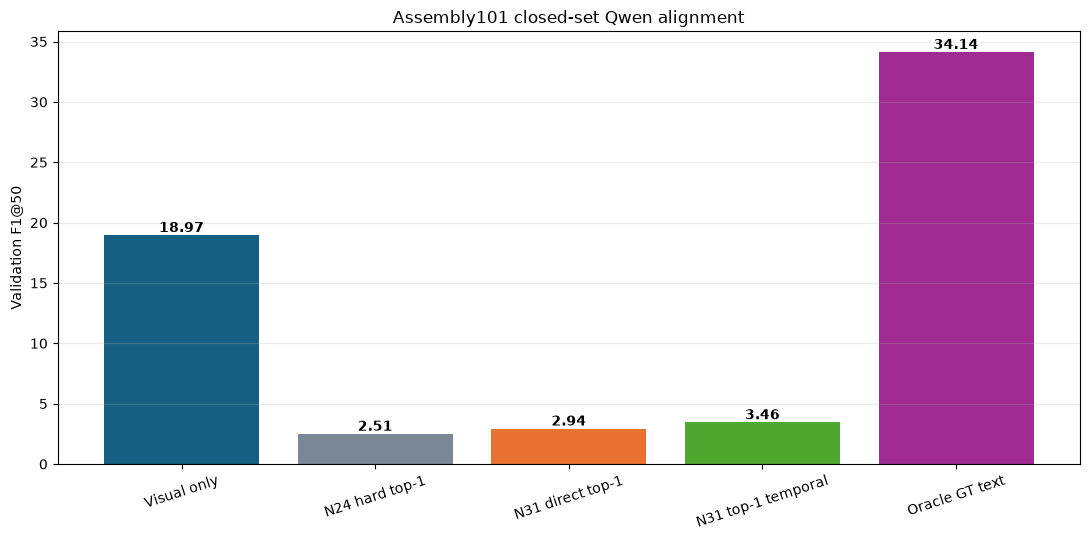

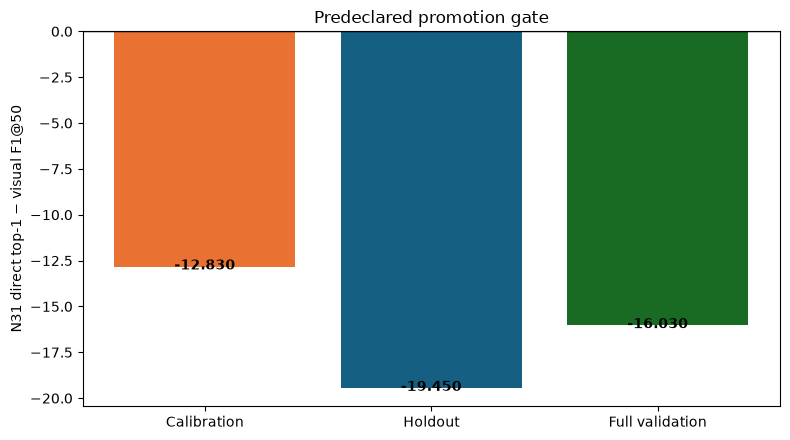

{
  "promote_to_test": false,
  "primary_full_f1@50": 2.94,
  "full_delta_vs_visual": -16.03,
  "calibration_delta_vs_visual": -12.83,
  "holdout_delta_vs_visual": -19.45,
  "top1_accuracy_percent": 2.864583333333333,
  "candidate_recall_at_k_percent": 2.864583333333333,
  "next_step": "Do not run on test; report the closed-set Qwen follow-up as negative or inconclusive."
}


In [72]:
plot_keys = [
    "visual_only_mstcn",
    "n24_hard_top1",
    "n31_top1",
    "n31_top1_temporal",
    "oracle_gt_text",
]
plot_names = [
    "Visual only",
    "N24 hard top-1",
    "N31 direct top-1",
    "N31 top-1 temporal",
    "Oracle GT text",
]
plot_values = [f1_value(key, "full_validation") for key in plot_keys]
colors = ["#156082", "#7A8797", "#E97132", "#4EA72E", "#A02B93"]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(plot_names, plot_values, color=colors)
ax.set_ylabel("Validation F1@50")
ax.set_title("Assembly101 closed-set Qwen alignment")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=18)
for bar, value in zip(bars, plot_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.25, f"{value:.2f}", ha="center", fontweight="bold")
fig.tight_layout()
f1_figure_path = LOCAL_ARTIFACT_DIR / "closed_set_qwen_f1_at_50.png"
fig.savefig(f1_figure_path, dpi=180, bbox_inches="tight")
plt.show()

delta_names = ["Calibration", "Holdout", "Full validation"]
delta_values = [
    decision["calibration_delta_vs_visual"],
    decision["holdout_delta_vs_visual"],
    decision["full_delta_vs_visual"],
]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(delta_names, delta_values, color=["#E97132", "#156082", "#196B24"])
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("N31 direct top-1 − visual F1@50")
ax.set_title("Predeclared promotion gate")
for bar, value in zip(bars, delta_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + (0.05 if value >= 0 else -0.15), f"{value:+.3f}", ha="center", fontweight="bold")
fig.tight_layout()
gate_figure_path = LOCAL_ARTIFACT_DIR / "closed_set_qwen_gate_deltas.png"
fig.savefig(gate_figure_path, dpi=180, bbox_inches="tight")
plt.show()

final_summary = {
    "status": "completed",
    "task": "Assembly101 Qwen3.5 full-catalog direct top-1 action alignment",
    "model_id": QWEN_MODEL_ID,
    "catalog_classes": EXPECTED_NUM_CLASSES,
    "validation_ground_truth_classes_observed": int(diagnostics_df["target_id"].nunique()),
    "primary_metric": "F1@50",
    "primary_variant": PRIMARY_VARIANT,
    "test_accessed": False,
    "oracle_teacher_reproduction_passed": True,
    "oracle_reproduction_tolerance": ORACLE_REPRO_TOLERANCE,
    "generation": generation_summary,
    "pseudo_label_diagnostics": diagnostic_summary,
    "validation_metrics": split_metrics_df.to_dict(orient="records"),
    "decision": decision,
    "next_step": (
        "Freeze this exact configuration and evaluate it once on test."
        if decision["promote_to_test"]
        else "Do not run on test; report the closed-set Qwen follow-up as negative or inconclusive."
    ),
    "created_utc": datetime.now(timezone.utc).isoformat(),
}
save_json_local(LOCAL_OUT_ROOT / "final_summary.json", final_summary)

for local_path in [
    LOCAL_OUT_ROOT / "closed_set_diagnostics.csv",
    LOCAL_OUT_ROOT / "closed_set_diagnostic_summary.json",
    LOCAL_OUT_ROOT / "validation_split_metrics.csv",
    LOCAL_OUT_ROOT / "teacher_text_ablation.csv",
    LOCAL_OUT_ROOT / "validation_decision.json",
    LOCAL_OUT_ROOT / "final_summary.json",
    f1_figure_path,
    gate_figure_path,
]:
    destination_root = DRIVE_ARTIFACT_DIR if local_path.parent == LOCAL_ARTIFACT_DIR else DRIVE_OUT_ROOT
    copy_with_retry(local_path, destination_root / local_path.name)

print(json.dumps({
    "promote_to_test": decision["promote_to_test"],
    "primary_full_f1@50": decision["primary_full_f1@50"],
    "full_delta_vs_visual": decision["full_delta_vs_visual"],
    "calibration_delta_vs_visual": decision["calibration_delta_vs_visual"],
    "holdout_delta_vs_visual": decision["holdout_delta_vs_visual"],
    "top1_accuracy_percent": diagnostic_summary["top1_accuracy_percent"],
    "candidate_recall_at_k_percent": diagnostic_summary["candidate_recall_at_k_percent"],
    "next_step": final_summary["next_step"],
}, indent=2))

del teacher
gc.collect()
torch.cuda.empty_cache()


## Interpretation

- The relevant comparison is the predeclared `n31_top1` row, not whichever diagnostic variant happens to score highest.
- A higher direct top-1 accuracy without a teacher F1@50 gain means that class alignment improved locally but the frozen teacher still cannot use noisy pseudo-text reliably.
- A positive full-validation result is insufficient if the holdout delta is negative.
- Only `promote_to_test = true` justifies one final, locked test-set run.
